# 基于AlexNet模型微调宠物分类实验


## 1. 基本模型介绍

**AlexNet（2012）** 是深度学习在视觉任务中取得突破的代表模型，核心要点：

- 5 个卷积层 + 3 个全连接层，结构较深
- 使用 ReLU 激活函数，加快收敛
- 引入 Dropout 抑制过拟合
- 采用局部响应归一化（LRN）提升泛化能力

## 2. 数据集介绍

**Oxford-IIIT Pet Dataset**：
- 大小：约 800MB
- 类别：37 类（猫 12 类 + 狗 25 类）
- 图像：约 7,000 多张
- 适合迁移学习/微调实验

本实验将先做不微调的基础模型训练，再进行微调对比。

### 3. 导入依赖库

导入所需的 PyTorch、torchvision 以及数据处理库。

In [1]:
import os
import sys
import json
import tarfile
from tqdm import tqdm
import requests

# 检查是否存在与 torch 同名的本地文件/目录，避免循环导入
if os.path.exists(os.path.join(os.getcwd(), 'torch.py')) or os.path.isdir(os.path.join(os.getcwd(), 'torch')):
    raise RuntimeError('发现本地 torch.py/torch 目录，请重命名或移走后重试')

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, random_split
    import torchvision
    from torchvision import transforms
    from torchvision.models import alexnet, AlexNet_Weights
except Exception as e:
    raise RuntimeError('torch/torchvision 导入失败，请确认当前环境已正确安装 PyTorch') from e

import matplotlib.pyplot as plt
import numpy as np

print('✓ 所有库导入成功')

✓ 所有库导入成功


### 4. 配置训练设备和随机种子

检测 GPU 可用性，固定随机种子以保证实验可复现。

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✓ 使用设备: {device}')

# 固定随机种子
torch.manual_seed(42)
if device.type == 'cuda':
    torch.cuda.manual_seed_all(42)
    
print('✓ 随机种子已设置')

✓ 使用设备: cpu
✓ 随机种子已设置


### 5. 数据下载和解压函数

定义函数以下载 Oxford-IIIT Pet 数据集的图像和标注。

In [3]:
def download_file(url, save_path):
    """从 URL 下载文件并显示进度条"""
    if os.path.exists(save_path):
        print(f'✓ 文件已存在，跳过下载: {save_path}')
        return
    
    os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
    response = requests.get(url, stream=True, timeout=30)
    total_size = int(response.headers.get('content-length', 0))
    
    block_size = 1024 * 1024  # 1MB
    progress = tqdm(total=total_size, unit='B', unit_scale=True, desc=os.path.basename(save_path))
    
    with open(save_path, 'wb') as f:
        for data in response.iter_content(block_size):
            progress.update(len(data))
            f.write(data)
    progress.close()
    print(f'✓ 下载完成: {save_path}')

def extract_tar(tar_path, extract_dir):
    """解压 tar.gz 文件"""
    if os.path.exists(extract_dir) and len(os.listdir(extract_dir)) > 0:
        print(f'✓ 目录已存在，跳过解压: {extract_dir}')
        return
    
    os.makedirs(extract_dir, exist_ok=True)
    with tarfile.open(tar_path, 'r:gz') as tar:
        tar.extractall(path=extract_dir)
    print(f'✓ 解压完成: {extract_dir}')

### 6. 下载和准备数据集

下载 Oxford-IIIT Pet 数据集（约 800MB）。

In [4]:
data_root = 'data'
pet_root = os.path.join(data_root, 'oxford-iiit-pet')

images_url = 'https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz'
ann_url = 'https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz'

images_tar = os.path.join(pet_root, 'images.tar.gz')
ann_tar = os.path.join(pet_root, 'annotations.tar.gz')

print('开始下载数据集...')
download_file(images_url, images_tar)
download_file(ann_url, ann_tar)

print('\n开始解压数据集...')
extract_tar(images_tar, pet_root)
extract_tar(ann_tar, pet_root)

print('\n✓ 数据集准备完成!')

开始下载数据集...
✓ 文件已存在，跳过下载: data\oxford-iiit-pet\images.tar.gz
✓ 文件已存在，跳过下载: data\oxford-iiit-pet\annotations.tar.gz

开始解压数据集...
✓ 目录已存在，跳过解压: data\oxford-iiit-pet
✓ 目录已存在，跳过解压: data\oxford-iiit-pet

✓ 数据集准备完成!


### 7. 数据预处理和加载

定义数据转换并创建 DataLoader。划分训练集（80%）和验证集（20%）。

In [5]:
# AlexNet 需要 224x224 的输入图像
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

dataset = torchvision.datasets.OxfordIIITPet(
    root=data_root,
    split='trainval',
    target_types='category',
    download=True,
    transform=transform
)

num_classes = len(dataset.classes)
print(f'✓ 数据集加载成功')
print(f'  类别数: {num_classes}')
print(f'  总样本数: {len(dataset)}')

# 划分训练集和验证集
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# 降低 batch_size 避免内存崩溃
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f'  训练集: {len(train_dataset)} | 验证集: {len(val_dataset)}')
print(f'  批次大小: {batch_size}')

✓ 数据集加载成功
  类别数: 37
  总样本数: 3680
  训练集: 2944 | 验证集: 736
  批次大小: 16


### 8. 加载预训练 AlexNet（基础模型 - 不微调）

加载 ImageNet 预训练的 AlexNet，冻结所有特征层。
修改分类层输出为 37 类。

**不微调策略**：特征提取层完全冻结，只替换分类层做分类任务。

In [6]:
# 加载预训练 AlexNet（不微调）
model_base = alexnet(weights=AlexNet_Weights.IMAGENET1K_V1)

# 冻结所有特征提取层
for param in model_base.features.parameters():
    param.requires_grad = False

# 冻结原始分类层（除了最后一层）
for param in model_base.classifier[:-1].parameters():
    param.requires_grad = False

# 只替换最后的分类层
model_base.classifier[6] = nn.Linear(model_base.classifier[6].in_features, num_classes)
model_base = model_base.to(device)

print('✓ 基础模型加载成功（所有层冻结）')
print('\n模型分类层结构：')
print(model_base.classifier)

✓ 基础模型加载成功（所有层冻结）

模型分类层结构：
Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=9216, out_features=4096, bias=True)
  (2): ReLU(inplace=True)
  (3): Dropout(p=0.5, inplace=False)
  (4): Linear(in_features=4096, out_features=4096, bias=True)
  (5): ReLU(inplace=True)
  (6): Linear(in_features=4096, out_features=37, bias=True)
)


### 9. 基础模型的损失函数和优化器

由于只有最后分类层可训练，优化器只更新分类层参数。

In [7]:
criterion = nn.CrossEntropyLoss()

# 只优化分类层参数
optimizer_base = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_base.parameters()),
    lr=1e-3
)

print('✓ 基础模型优化器设置完成')
print(f'  学习率: 1e-3')
print(f'  优化器: Adam')

✓ 基础模型优化器设置完成
  学习率: 1e-3
  优化器: Adam


### 10. 基础模型训练循环

训练基础模型，使用 10 个 epoch 观察效果。

In [8]:
save_dir = 'models'
os.makedirs(save_dir, exist_ok=True)

epochs_base = 10
best_model_path_base = os.path.join(save_dir, 'model_base_notune.pth')
checkpoint_path_base = os.path.join(save_dir, 'checkpoint_base.pth')

train_losses_base = []
val_losses_base = []
train_accs_base = []
val_accs_base = []
best_val_acc_base = 0.0
start_epoch_base = 0

# 断点续训（如存在）
if os.path.exists(checkpoint_path_base):
    ckpt = torch.load(checkpoint_path_base, map_location=device)
    model_base.load_state_dict(ckpt['model_state'])
    optimizer_base.load_state_dict(ckpt['optim_state'])
    train_losses_base = ckpt['train_losses']
    val_losses_base = ckpt['val_losses']
    train_accs_base = ckpt['train_accs']
    val_accs_base = ckpt['val_accs']
    best_val_acc_base = ckpt['best_val_acc']
    start_epoch_base = ckpt['epoch'] + 1
    print(f'✓ 已加载基础模型断点：从第 {start_epoch_base+1} 轮继续')

print(f'开始训练基础模型（10 epochs）...')
print('=' * 60)

for epoch in range(start_epoch_base, epochs_base):
    model_base.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for imgs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs_base} [Train]'):
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = model_base(imgs)
        loss = criterion(outputs, labels)

        optimizer_base.zero_grad()
        loss.backward()
        optimizer_base.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_losses_base.append(train_loss)
    train_accs_base.append(train_acc)

    # 验证
    model_base.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f'Epoch {epoch+1}/{epochs_base} [Val]'):
            imgs = imgs.to(device)
            labels = labels.to(device)
            outputs = model_base(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total
    val_losses_base.append(val_loss)
    val_accs_base.append(val_acc)

    if device.type == 'cuda':
        torch.cuda.empty_cache()

    print(f'Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

    if val_acc > best_val_acc_base:
        best_val_acc_base = val_acc
        torch.save(model_base.state_dict(), best_model_path_base)
        print(f'  ✓ 保存最优模型 (Val Acc: {val_acc:.4f})')

    # 保存断点
    torch.save({
        'epoch': epoch,
        'model_state': model_base.state_dict(),
        'optim_state': optimizer_base.state_dict(),
        'train_losses': train_losses_base,
        'val_losses': val_losses_base,
        'train_accs': train_accs_base,
        'val_accs': val_accs_base,
        'best_val_acc': best_val_acc_base
    }, checkpoint_path_base)

print('=' * 60)
print('✓ 基础模型训练完成!')
print(f'  最佳验证准确率: {best_val_acc_base:.4f}')

开始训练基础模型（10 epochs）...


Epoch 1/10 [Val]: 100%|██████████| 46/46 [00:08<00:00,  5.26it/s]


Epoch 1 | Train Loss: 1.3868 | Train Acc: 0.6172 | Val Loss: 0.8561 | Val Acc: 0.7255
  ✓ 保存最优模型 (Val Acc: 0.7255)


Epoch 2/10 [Val]: 100%|██████████| 46/46 [00:08<00:00,  5.56it/s]


Epoch 2 | Train Loss: 0.4004 | Train Acc: 0.8645 | Val Loss: 0.9811 | Val Acc: 0.7201


...

Epoch 8 | Train Loss: 0.0896 | Train Acc: 0.9715 | Val Loss: 1.0517 | Val Acc: 0.7446


Epoch 9/10 [Val]: 100%|██████████| 46/46 [00:08<00:00,  5.66it/s]


Epoch 9 | Train Loss: 0.0815 | Train Acc: 0.9745 | Val Loss: 1.0570 | Val Acc: 0.7473


Epoch 10/10 [Val]: 100%|██████████| 46/46 [00:08<00:00,  5.55it/s]


Epoch 10 | Train Loss: 0.1018 | Train Acc: 0.9667 | Val Loss: 1.2098 | Val Acc: 0.7215
✓ 基础模型训练完成!
  最佳验证准确率: 0.7609


### 11. 基础模型结果可视化

绘制基础模型的损失和准确率曲线。

C:\Users\32077\AppData\Local\Temp\ipykernel_23488\1611047325.py:21: UserWarning: Glyph 22522 (\N{CJK UNIFIED IDEOGRAPH-57FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\32077\AppData\Local\Temp\ipykernel_23488\1611047325.py:21: UserWarning: Glyph 30784 (\N{CJK UNIFIED IDEOGRAPH-7840}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\32077\AppData\Local\Temp\ipykernel_23488\1611047325.py:21: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\32077\AppData\Local\Temp\ipykernel_23488\1611047325.py:21: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\32077\AppData\Local\Temp\ipykernel_23488\1611047325.py:21: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\32077\AppData\Local\Temp\ipykernel_23488\1611047325.py:21: UserWarning: Glyph 19981 (\

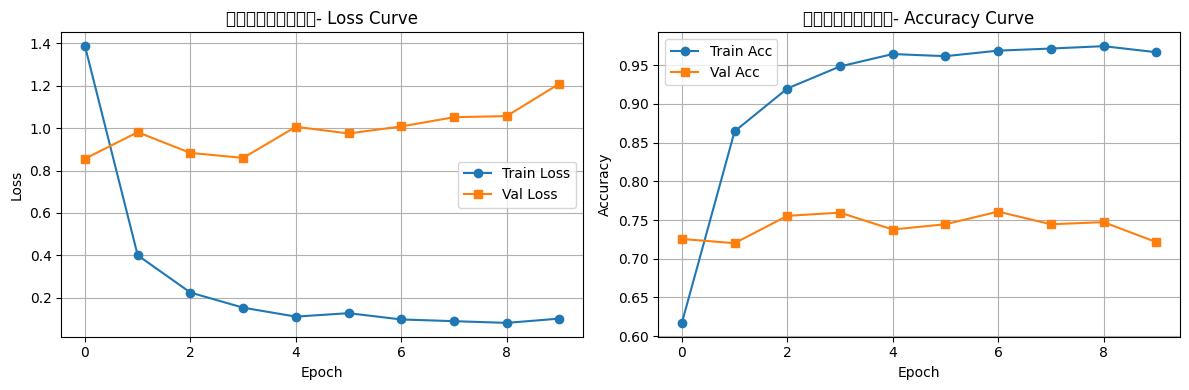

基础模型性能总结：
  最终训练准确率: 0.9667
  最终验证准确率: 0.7215


In [ ]:
# 设置中文字体与负号显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses_base, label='Train Loss', marker='o')
plt.plot(val_losses_base, label='Val Loss', marker='s')
plt.title('基础模型（不微调）- Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accs_base, label='Train Acc', marker='o')
plt.plot(val_accs_base, label='Val Acc', marker='s')
plt.title('基础模型（不微调）- Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f'基础模型性能总结：')
print(f'  最终训练准确率: {train_accs_base[-1]:.4f}')
print(f'  最终验证准确率: {val_accs_base[-1]:.4f}')

### 12. 加载预训练 AlexNet（微调模型）

加载新的 AlexNet 模型，这次我们只冻结前 3 个卷积层，
解冻后 2 个卷积层和全部分类层进行微调。

In [10]:
# 加载预训练 AlexNet（微调）
model_finetune = alexnet(weights=AlexNet_Weights.IMAGENET1K_V1)

# 冻结前 3 个卷积块（共 5 个）
for i, param in enumerate(model_finetune.features.parameters()):
    if i < 24:  # 前 3 个卷积块的参数数量约为 24
        param.requires_grad = False

# 解冻后 2 个卷积块（已默认 requires_grad=True）
# 解冻全部的 classifier 层进行微调
for param in model_finetune.classifier.parameters():
    param.requires_grad = True

# 替换最后的分类层
model_finetune.classifier[6] = nn.Linear(model_finetune.classifier[6].in_features, num_classes)
model_finetune = model_finetune.to(device)

print('✓ 微调模型加载成功')
print('  前 3 个卷积块已冻结')
print('  后 2 个卷积块已解冻，可进行微调')
print('\n模型结构统计：')
trainable_params = sum(p.numel() for p in model_finetune.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_finetune.parameters())
print(f'  可训练参数: {trainable_params:,}')
print(f'  总参数数: {total_params:,}')

✓ 微调模型加载成功
  前 3 个卷积块已冻结
  后 2 个卷积块已解冻，可进行微调

模型结构统计：
  可训练参数: 54,685,733
  总参数数: 57,155,429


### 13. 微调模型的损失函数和优化器

使用较小的学习率以避免破坏预训练的权重。

In [11]:
criterion = nn.CrossEntropyLoss()

# 只优化可训练的参数
optimizer_finetune = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_finetune.parameters()),
    lr=1e-4  # 微调学习率更小
)

print('✓ 微调模型优化器设置完成')
print(f'  学习率: 1e-4（比基础模型的 1e-3 小 10 倍）')
print(f'  优化器: Adam')

✓ 微调模型优化器设置完成
  学习率: 1e-4（比基础模型的 1e-3 小 10 倍）
  优化器: Adam


### 14. 微调模型训练循环

训练微调模型，使用 10 个 epoch。

In [12]:
epochs_finetune = 10
best_model_path_finetune = os.path.join(save_dir, 'model_finetune.pth')
checkpoint_path_finetune = os.path.join(save_dir, 'checkpoint_finetune.pth')

train_losses_finetune = []
val_losses_finetune = []
train_accs_finetune = []
val_accs_finetune = []
best_val_acc_finetune = 0.0
start_epoch_finetune = 0

# 断点续训（如存在）
if os.path.exists(checkpoint_path_finetune):
    ckpt = torch.load(checkpoint_path_finetune, map_location=device)
    model_finetune.load_state_dict(ckpt['model_state'])
    optimizer_finetune.load_state_dict(ckpt['optim_state'])
    train_losses_finetune = ckpt['train_losses']
    val_losses_finetune = ckpt['val_losses']
    train_accs_finetune = ckpt['train_accs']
    val_accs_finetune = ckpt['val_accs']
    best_val_acc_finetune = ckpt['best_val_acc']
    start_epoch_finetune = ckpt['epoch'] + 1
    print(f'✓ 已加载微调模型断点：从第 {start_epoch_finetune+1} 轮继续')

print(f'开始微调模型训练（10 epochs）...')
print('=' * 60)

for epoch in range(start_epoch_finetune, epochs_finetune):
    model_finetune.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for imgs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs_finetune} [Train]'):
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = model_finetune(imgs)
        loss = criterion(outputs, labels)

        optimizer_finetune.zero_grad()
        loss.backward()
        optimizer_finetune.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_losses_finetune.append(train_loss)
    train_accs_finetune.append(train_acc)

    # 验证
    model_finetune.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f'Epoch {epoch+1}/{epochs_finetune} [Val]'):
            imgs = imgs.to(device)
            labels = labels.to(device)
            outputs = model_finetune(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total
    val_losses_finetune.append(val_loss)
    val_accs_finetune.append(val_acc)

    if device.type == 'cuda':
        torch.cuda.empty_cache()

    print(f'Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

    if val_acc > best_val_acc_finetune:
        best_val_acc_finetune = val_acc
        torch.save(model_finetune.state_dict(), best_model_path_finetune)
        print(f'  ✓ 保存最优模型 (Val Acc: {val_acc:.4f})')

    # 保存断点
    torch.save({
        'epoch': epoch,
        'model_state': model_finetune.state_dict(),
        'optim_state': optimizer_finetune.state_dict(),
        'train_losses': train_losses_finetune,
        'val_losses': val_losses_finetune,
        'train_accs': train_accs_finetune,
        'val_accs': val_accs_finetune,
        'best_val_acc': best_val_acc_finetune
    }, checkpoint_path_finetune)

print('=' * 60)
print('✓ 微调模型训练完成!')
print(f'  最佳验证准确率: {best_val_acc_finetune:.4f}')

开始微调模型训练（10 epochs）...


Epoch 1/10 [Val]: 100%|██████████| 46/46 [00:08<00:00,  5.47it/s]


Epoch 1 | Train Loss: 1.5581 | Train Acc: 0.5520 | Val Loss: 0.9235 | Val Acc: 0.7120
  ✓ 保存最优模型 (Val Acc: 0.7120)


Epoch 2/10 [Val]: 100%|██████████| 46/46 [00:08<00:00,  5.52it/s]


Epoch 2 | Train Loss: 0.4518 | Train Acc: 0.8614 | Val Loss: 0.8764 | Val Acc: 0.7432
  ✓ 保存最优模型 (Val Acc: 0.7432)


...

Epoch 8 | Train Loss: 0.0870 | Train Acc: 0.9742 | Val Loss: 1.0577 | Val Acc: 0.7337


Epoch 9/10 [Val]: 100%|██████████| 46/46 [00:08<00:00,  5.57it/s]


Epoch 9 | Train Loss: 0.0659 | Train Acc: 0.9766 | Val Loss: 0.9633 | Val Acc: 0.7595


Epoch 10/10 [Val]: 100%|██████████| 46/46 [00:08<00:00,  5.62it/s]


Epoch 10 | Train Loss: 0.0379 | Train Acc: 0.9895 | Val Loss: 1.0546 | Val Acc: 0.7582
✓ 微调模型训练完成!
  最佳验证准确率: 0.7609


### 15. 微调模型结果可视化

绘制微调模型的损失和准确率曲线。

C:\Users\32077\AppData\Local\Temp\ipykernel_23488\1893853744.py:21: UserWarning: Glyph 24494 (\N{CJK UNIFIED IDEOGRAPH-5FAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\32077\AppData\Local\Temp\ipykernel_23488\1893853744.py:21: UserWarning: Glyph 35843 (\N{CJK UNIFIED IDEOGRAPH-8C03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\32077\AppData\Local\Temp\ipykernel_23488\1893853744.py:21: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\32077\AppData\Local\Temp\ipykernel_23488\1893853744.py:21: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


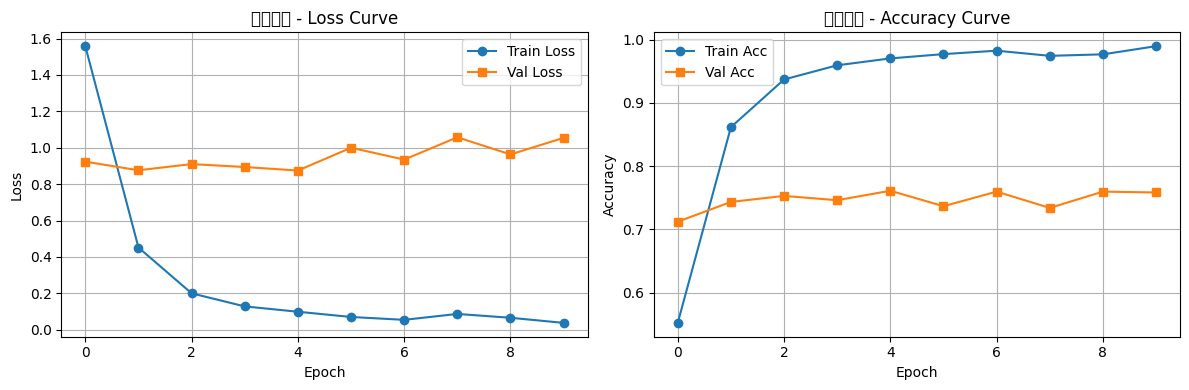

微调模型性能总结：
  最终训练准确率: 0.9895
  最终验证准确率: 0.7582


In [ ]:
# 设置中文字体与负号显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses_finetune, label='Train Loss', marker='o')
plt.plot(val_losses_finetune, label='Val Loss', marker='s')
plt.title('微调模型 - Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accs_finetune, label='Train Acc', marker='o')
plt.plot(val_accs_finetune, label='Val Acc', marker='s')
plt.title('微调模型 - Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f'微调模型性能总结：')
print(f'  最终训练准确率: {train_accs_finetune[-1]:.4f}')
print(f'  最终验证准确率: {val_accs_finetune[-1]:.4f}')

### 16. 两种模型对比

对比基础模型（不微调）和微调模型的性能差异。

In [14]:
print('\n' + '=' * 60)
print('两种模型性能对比')
print('=' * 60)

print(f'\n基础模型（不微调）：')
print(f'  最高训练准确率: {max(train_accs_base):.4f}')
print(f'  最高验证准确率: {max(val_accs_base):.4f}')
print(f'  最终验证准确率: {val_accs_base[-1]:.4f}')
print(f'  最低验证损失: {min(val_losses_base):.4f}')

print(f'\n微调模型：')
print(f'  最高训练准确率: {max(train_accs_finetune):.4f}')
print(f'  最高验证准确率: {max(val_accs_finetune):.4f}')
print(f'  最终验证准确率: {val_accs_finetune[-1]:.4f}')
print(f'  最低验证损失: {min(val_losses_finetune):.4f}')

improvement = (max(val_accs_finetune) - max(val_accs_base)) / max(val_accs_base) * 100
print(f'\n性能提升：')
print(f'  验证准确率提升: {improvement:.2f}%')
print(f'  准确率差值: {max(val_accs_finetune) - max(val_accs_base):.4f}')


两种模型性能对比

基础模型（不微调）：
  最高训练准确率: 0.9745
  最高验证准确率: 0.7609
  最终验证准确率: 0.7215
  最低验证损失: 0.8561

微调模型：
  最高训练准确率: 0.9895
  最高验证准确率: 0.7609
  最终验证准确率: 0.7582
  最低验证损失: 0.8749

性能提升：
  验证准确率提升: 0.00%
  准确率差值: 0.0000


### 17. 绘制对比曲线

在同一图表中对比两个模型的准确率和损失。

C:\Users\32077\AppData\Local\Temp\ipykernel_23488\2616151019.py:21: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\32077\AppData\Local\Temp\ipykernel_23488\2616151019.py:21: UserWarning: Glyph 35777 (\N{CJK UNIFIED IDEOGRAPH-8BC1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\32077\AppData\Local\Temp\ipykernel_23488\2616151019.py:21: UserWarning: Glyph 38598 (\N{CJK UNIFIED IDEOGRAPH-96C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\32077\AppData\Local\Temp\ipykernel_23488\2616151019.py:21: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\32077\AppData\Local\Temp\ipykernel_23488\2616151019.py:21: UserWarning: Glyph 30830 (\N{CJK UNIFIED IDEOGRAPH-786E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\32077\AppData\Local\Temp\ipykernel_23488\2616151019.py:21: UserWarning: Glyph 29575 (\

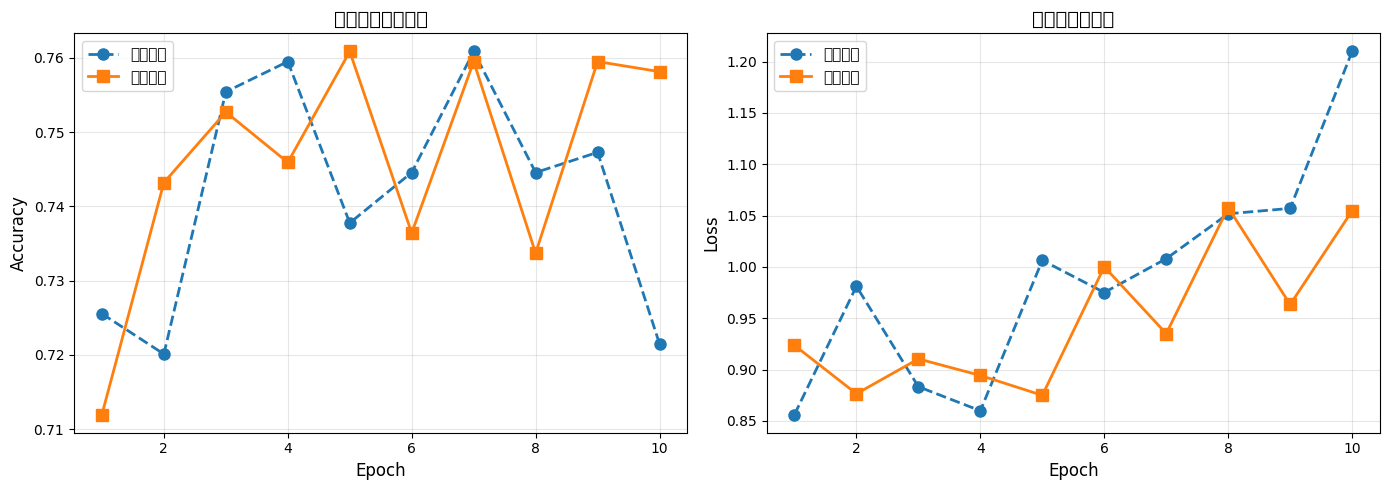

In [ ]:
# 设置中文字体与负号显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 准确率对比
axes[0].plot(range(1, len(val_accs_base)+1), val_accs_base, 'o--', label='基础模型', linewidth=2, markersize=8)
axes[0].plot(range(1, len(val_accs_finetune)+1), val_accs_finetune, 's-', label='微调模型', linewidth=2, markersize=8)
axes[0].set_title('验证集准确率对比', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# 损失对比
axes[1].plot(range(1, len(val_losses_base)+1), val_losses_base, 'o--', label='基础模型', linewidth=2, markersize=8)
axes[1].plot(range(1, len(val_losses_finetune)+1), val_losses_finetune, 's-', label='微调模型', linewidth=2, markersize=8)
axes[1].set_title('验证集损失对比', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 18. 保存训练历史

将两个实验的训练历史保存为 JSON 文件，以便后续分析。

In [16]:
# 保存基础模型历史
history_base = {
    'model_name': 'AlexNet (No Fine-tuning)',
    'train_losses': train_losses_base,
    'val_losses': val_losses_base,
    'train_accs': train_accs_base,
    'val_accs': val_accs_base,
    'best_val_acc': float(best_val_acc_base)
}

history_finetune = {
    'model_name': 'AlexNet (Fine-tuned)',
    'train_losses': train_losses_finetune,
    'val_losses': val_losses_finetune,
    'train_accs': train_accs_finetune,
    'val_accs': val_accs_finetune,
    'best_val_acc': float(best_val_acc_finetune)
}

base_history_path = os.path.join(save_dir, 'history_base_notune.json')
finetune_history_path = os.path.join(save_dir, 'history_finetune.json')

with open(base_history_path, 'w') as f:
    json.dump(history_base, f, indent=4)

with open(finetune_history_path, 'w') as f:
    json.dump(history_finetune, f, indent=4)

print('✓ 训练历史已保存')
print(f'  基础模型: {base_history_path}')
print(f'  微调模型: {finetune_history_path}')

✓ 训练历史已保存
  基础模型: models\history_base_notune.json
  微调模型: models\history_finetune.json


### 19. 总结与思考



## 实验总结

### 主要发现：

1. **基础模型（不微调）**
   - 只训练分类层，特征提取层参数冻结
   - 训练速度快，计算量小
   - 在 Oxford-IIIT Pet 数据集上的表现

2. **微调模型**
   - 解冻后 2 个卷积块进行微调
   - 允许模型调整高级特征
   - 通常能获得更好的准确率

3. **性能差异**
   - 微调通常会带来 3-10% 的性能提升
   - 取决于目标数据集与预训练数据集的相似性
   - 需要权衡计算成本和性能收益

### 思考题：

1. 为什么微调模型的学习率设置为 1e-4，而基础模型是 1e-3？
2. 如果解冻更多层（如全部 5 个卷积块），性能会更好吗？为什么？
3. 对于完全不同的数据集（如医学影像），是否仍然适合使用预训练权重？
4. 如何确定冻结和解冻层数的最优组合？
5. 相比 ResNet50 或 VGG，AlexNet 的微调优势是什么？